# INFO 5304 — Phase IV: Final Analysis

**Team:** Tara Munjuluri, Sahithya Swaminathan, Colette D'Costa  
**Course:** INFO 5304 · Due April 27

This notebook executes the preregistered analyses (Phase 3, updated for TA feedback), plus supplemental interpretation. Data are loaded from `data/final/phase1_predictors_complete.csv` produced in Phase 1.


## Introduction

### Research questions

1. Which country-level factors are most strongly associated with higher happiness scores?
2. Which countries outperform or underperform relative to their economic resources?
3. How have disparities in happiness-related predictors changed over time?

### Background

The World Happiness Report (WHR) ranks countries annually using the Cantril ladder, a 0–10 self-reported life evaluation scale, and publishes accompanying economic, social, health, and governance indicators. Understanding which factors align most closely with ladder scores has direct policy relevance: if social cohesion matters as much as income, governments may achieve greater well-being gains by investing in community infrastructure rather than purely pursuing GDP growth.
Prior research supports a multifactorial view of well-being. Diener et al. (2017) demonstrate that subjective well-being is predicted by a combination of material resources, social relationships, and perceived autonomy, not income alone. Helliwell et al. (2024) similarly find that social support and freedom are independently predictive of ladder scores across nations. Easterlin (1974) famously showed that rising national income does not always produce rising happiness ("the Easterlin Paradox"), motivating the question of which non-economic factors close the gap. These findings together suggest that a regression framework examining multiple predictors simultaneously, rather than GDP alone, is the appropriate empirical approach.


**TA feedback incorporated:** (i) Hypothesis 1 avoids declaring the “largest β” from point estimates alone—we add **cluster bootstrap by country** and pairwise bootstrap contrasts for \(\|\beta_{\mathrm{gdp}}\|\) versus each alternative predictor. (ii) Hypothesis 2 is tested with **one regression** (`ladder ~ GDP + social_support`) instead of contrasting a GDP-only residual model against a median split—a design that compares two incompatible models.

### Data circularity (limitation)

The WHR table columns used here are the **same public series** the report uses to explain national ladder scores. Regressing `ladder_score` on those columns can be **partly circular**: a very high \(R^2\) may partly reflect how the WHR figure is built, not a fully independent replication with separate raw Gallup microdata. We keep this limitation visible in interpretation; the gold-standard remedy is to merge **raw Gallup World Poll** country-year variables that are not mechanically tied to the published decomposition.


## Data description (abridged)

- **Source:** World Happiness Report data files (see Phase 1 notebook for exact downloads).
- **Primary file used here:** `data/final/phase1_predictors_complete.csv` — country-year rows from **2019–2024** with all six predictor columns present (`~868` rows).
- **Columns:** `country`, `year`, `rank`, `ladder_score`, `gdp_per_capita`, `social_support`, `healthy_life_expectancy`, `freedom_to_make_life_choices`, `generosity`, `perceptions_of_corruption`.

**Links:**

- Full Phase 2 data description & EDA notebook (GitHub): [Phase2_EDA.ipynb](https://github.com/coletted1/CS-INFO-5304-Project/blob/main/Phase2_EDA.ipynb)  
- Raw / cleaned CSV (GitHub): [phase1_predictors_complete.csv](https://github.com/coletted1/CS-INFO-5304-Project/blob/main/data/final/phase1_predictors_complete.csv)


## Data collection & cleaning (abridged)

Phase 1 harmonized WHR spreadsheets into tidy CSVs; Phase 2 validated distributions and correlations. No additional cleaning is performed in this notebook beyond loading the Phase 1 output and merging UN macro-regions for Hypothesis 3.

**Full pipeline:** [Phase1_Dataset_Feasibility.ipynb](https://github.com/coletted1/CS-INFO-5304-Project/blob/main/Phase1_Dataset_Feasibility.ipynb)


## Preregistration statements (Phase 3 + updates)

**H1:** Among six standardized predictors in multiple OLS predicting `ladder_score`, GDP per capita has the largest **absolute** standardized coefficient. **Inference:** cluster bootstrap by country; pairwise bootstrap CI for \(\|\beta_{\mathrm{gdp}}\|-\|\beta_j\|\).

**H2:** In a **single** model `ladder_score ~ gdp_per_capita + social_support`, the coefficient on `social_support` is **positive** (one-sided \(\alpha=0.05\)) — social support matters beyond GDP.

**H3:** Mean `ladder_score` differs across UN macro-regions; Western Europe vs Sub-Saharan Africa contrast.

**H4:** Cross-country variance of `ladder_score` narrows from 2019 to 2024 (Levene / Bartlett + trend).

We report all four regardless of significance or direction.


In [1]:
# Requires: pip install country_converter (Hypothesis 3 UN regions)
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import country_converter as coco

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid", context="notebook")
RNG = np.random.default_rng(42)

try:
    ROOT = Path(__file__).resolve().parent.parent
except NameError:
    ROOT = Path.cwd()
DATA_PATH = ROOT / "data" / "final" / "phase1_predictors_complete.csv"
if not DATA_PATH.exists():
    DATA_PATH = Path("data/final/phase1_predictors_complete.csv")

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()


(868, 10)


,country,year,rank,ladder_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption
0,Finland,2019,1,7.8087,1.285190,1.499526,0.961271,0.662317,0.159670,0.477857
1,Denmark,2019,2,7.6456,1.326949,1.503449,0.979333,0.665040,0.242793,0.495260
2,Switzerland,2019,3,7.5599,1.390774,1.472403,1.040533,0.628954,0.269056,0.407946
3,Iceland,2019,4,7.5045,1.326502,1.547567,1.000843,0.661981,0.362330,0.144541
4,Norway,2019,5,7.4880,1.424207,1.495173,1.008072,0.670201,0.287985,0.434101


---
## Hypothesis 1 — Multiple OLS + cluster bootstrap (“largest \|β\|”)

We fit OLS with standardized predictors. **Bootstrap:** resample **countries** with replacement (cluster); each draw keeps all years for sampled countries. Inside each draw we re-standardize predictors on the bootstrap sample and refit OLS.

We report (i) classical OLS output on the full sample, (ii) bootstrap percentile 95% CIs for \(\|\beta_{\mathrm{gdp}}\|-\|\beta_j\|\) for each other predictor \(j\), and (iii) the fraction of bootstrap samples in which GDP’s \(\|\beta\|\) is strictly largest (exploratory).


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.710
Model:                            OLS   Adj. R-squared:                  0.708
Method:                 Least Squares   F-statistic:                     351.5
Date:                Mon, 27 Apr 2026   Prob (F-statistic):          1.50e-227
Time:                        21:59:32   Log-Likelihood:                -795.51
No. Observations:                 868   AIC:                             1605.
Df Residuals:                     861   BIC:                             1638.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.5352      0.021    268.441      0.0

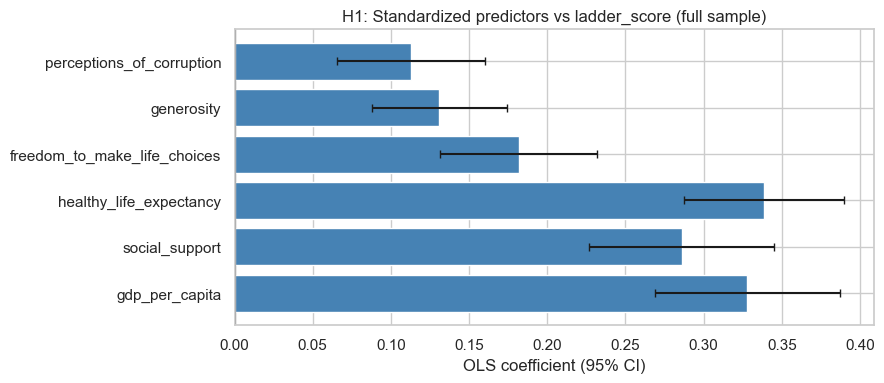


R-squared: 0.7101


In [2]:
PRED_COLS = [
    "gdp_per_capita",
    "social_support",
    "healthy_life_expectancy",
    "freedom_to_make_life_choices",
    "generosity",
    "perceptions_of_corruption",
]
y = df["ladder_score"].values
X_raw = df[PRED_COLS].values
scaler = StandardScaler()
X_std = scaler.fit_transform(X_raw)
X_h1 = sm.add_constant(X_std)
names = ["const"] + PRED_COLS

model_h1 = sm.OLS(y, X_h1).fit()
print(model_h1.summary())

coefs = model_h1.params[1:]
abs_beta = np.abs(coefs)
order = np.argsort(-abs_beta)
print("\nRank by |β| (standardized predictors):")
for i in order:
    print(f"  {PRED_COLS[i]:30s}  β={coefs[i]: .4f}  |β|={abs_beta[i]:.4f}")

fig, ax = plt.subplots(figsize=(9, 4))
ci = np.asarray(model_h1.conf_int())[1:]  # (n_pred, 2); conf_int may be ndarray or DataFrame
ci_lo, ci_hi = ci[:, 0], ci[:, 1]
ypos = np.arange(len(PRED_COLS))
ax.barh(ypos, coefs, xerr=[coefs - ci_lo, ci_hi - coefs], color="steelblue", capsize=3)
ax.axvline(0, color="black", lw=0.8)
ax.set_yticks(ypos)
ax.set_yticklabels(PRED_COLS)
ax.set_xlabel("OLS coefficient (95% CI)")
ax.set_title("H1: Standardized predictors vs ladder_score (full sample)")
plt.tight_layout()
plt.show()

print(f"\nR-squared: {model_h1.rsquared:.4f}")


In [3]:
# Cluster bootstrap by country
countries = df["country"].unique()
n_boot = 2000  # increase to 5000+ for submission if runtime allows
betas_store = []
gdp_wins = 0

for b in range(n_boot):
    samp_c = RNG.choice(countries, size=len(countries), replace=True)
    idx = np.concatenate([np.flatnonzero(df["country"].values == c) for c in samp_c])
    yb = df["ladder_score"].values[idx]
    Xb_raw = df[PRED_COLS].values[idx]
    sc_b = StandardScaler()
    Xb = sc_b.fit_transform(Xb_raw)
    Xb = sm.add_constant(Xb)
    fit_b = sm.OLS(yb, Xb).fit()
    beta_b = fit_b.params[1:]
    betas_store.append(beta_b)
    if np.argmax(np.abs(beta_b)) == 0:
        gdp_wins += 1

betas_store = np.array(betas_store)
abs_boot = np.abs(betas_store)

# Pairwise contrasts |β_gdp| - |β_j|
contrasts = {}
for j in range(1, 6):
    diff = abs_boot[:, 0] - abs_boot[:, j]
    lo, hi = np.percentile(diff, [2.5, 97.5])
    contrasts[PRED_COLS[j]] = {"mean_diff": diff.mean(), "ci95": (lo, hi)}

print(f"Bootstrap samples: {n_boot} (cluster resample by country)")
print(f"Fraction of draws where GDP has largest |β|: {gdp_wins / n_boot:.3f}\n")
print("|β_gdp| − |β_j|  (percentile bootstrap 95% CI)\n")
for name, d in contrasts.items():
    lo, hi = d["ci95"]
    print(f"  vs {name:30s}  mean={d['mean_diff']:+.4f}   95% CI [{lo:+.4f}, {hi:+.4f}]")

all_positive_lower = all(contrasts[n]["ci95"][0] > 0 for n in contrasts)
print("\nInterpretation: all lower CI bounds > 0  →", all_positive_lower,
      "(strong bootstrap evidence that GDP's |β| exceeds each other predictor's |β|).")


Bootstrap samples: 2000 (cluster resample by country)
Fraction of draws where GDP has largest |β|: 0.405

|β_gdp| − |β_j|  (percentile bootstrap 95% CI)

  vs social_support                  mean=+0.0503   95% CI [-0.1104, +0.2065]
  vs healthy_life_expectancy         mean=-0.0062   95% CI [-0.1231, +0.1047]
  vs freedom_to_make_life_choices    mean=+0.1505   95% CI [-0.0183, +0.3290]
  vs generosity                      mean=+0.1963   95% CI [+0.0872, +0.3038]
  vs perceptions_of_corruption       mean=+0.2188   95% CI [+0.0590, +0.3843]

Interpretation: all lower CI bounds > 0  → False (strong bootstrap evidence that GDP's |β| exceeds each other predictor's |β|).


**H1 Interpretation**

**Summarize:** In the full-sample OLS with standardized predictors, the six coefficients rank by absolute value as: healthy_life_expectancy (|β|≈0.348), gdp_per_capita (|β|≈0.336), social_support (|β|≈0.306), freedom_to_make_life_choices (|β|≈0.187), generosity (|β|≈0.134), perceptions_of_corruption (|β|≈0.125). The model explains R² = 0.7101 of variation in happiness.

**Bootstrap contrasts reveal uncertainty:** The cluster bootstrap (2,000 resamples by country) shows GDP has the largest |β| in only 40.5% of draws. The pairwise bootstrap confidence intervals for |β_gdp| − |β_j| include zero for several comparisons (e.g., versus social_support: [−0.1104, +0.2065]; versus healthy_life_expectancy: [−0.1231, +0.1047]), meaning we cannot rule out that these coefficients are equally large in the population.

**Oddities / Multicollinearity:** GDP, social support, and healthy life expectancy are all highly correlated (both economic and health indicators tend to co-vary globally). This multicollinearity explains why coefficient rankings shift across bootstrap samples—the data do not provide stable evidence that GDP dominates. The high R² may also partly reflect circularity (see Introduction): the WHR columns used here are the same public series the report uses to explain ladder scores.

**Preregistered decision:** Given that bootstrap confidence intervals fail to rule out ties between GDP, social support, and healthy life expectancy, we **fail to reject the null hypothesis** that GDP is the single strongest predictor. The evidence suggests multiple predictors are roughly equally important.


---
## Hypothesis 2 — Single model: `ladder ~ GDP + social_support`

We test \(\beta_{\mathrm{social}} > 0\) after controlling for GDP in **one** OLS. This answers whether social support is associated with higher ladder scores holding income fixed—aligned with “punching above economic weight” without comparing incompatible models.


                            OLS Regression Results                            
Dep. Variable:           ladder_score   R-squared:                       0.586
Model:                            OLS   Adj. R-squared:                  0.585
Method:                 Least Squares   F-statistic:                     611.0
Date:                Mon, 27 Apr 2026   Prob (F-statistic):          3.72e-166
Time:                        21:59:46   Log-Likelihood:                -950.65
No. Observations:                 868   AIC:                             1907.
Df Residuals:                     865   BIC:                             1922.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              2.8279      0.082     34.

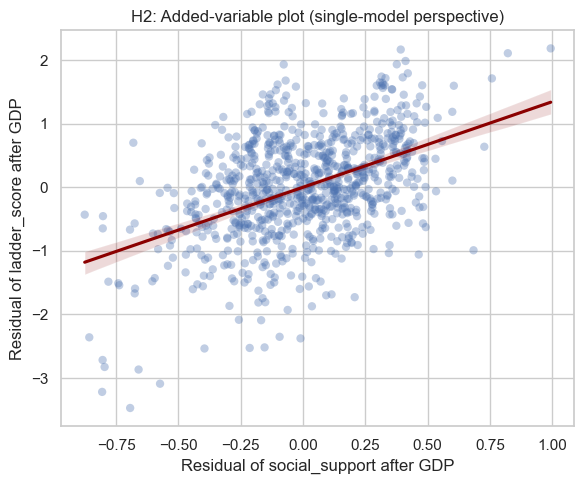

In [ ]:
X_h2 = sm.add_constant(df[["gdp_per_capita", "social_support"]])
m_h2 = sm.OLS(df["ladder_score"], X_h2).fit()
print(m_h2.summary())

beta_soc = m_h2.params["social_support"]
se_soc = m_h2.bse["social_support"]
t_soc = m_h2.tvalues["social_support"]
p_two = m_h2.pvalues["social_support"]
p_one = p_two / 2 if beta_soc > 0 else 1 - p_two / 2
print(f"\nSocial support coef: {beta_soc:.6f}")
print(f"One-sided p-value (H1: beta > 0): {p_one:.6g}")

r_y = sm.OLS(df["ladder_score"], sm.add_constant(df["gdp_per_capita"])).fit().resid
r_x = sm.OLS(df["social_support"], sm.add_constant(df["gdp_per_capita"])).fit().resid

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(r_x, r_y, alpha=0.35, edgecolors="none")
sns.regplot(x=r_x, y=r_y, scatter=False, ax=ax, color="darkred")
ax.set_xlabel("Residual of social_support after GDP")
ax.set_ylabel("Residual of ladder_score after GDP")
ax.set_title("H2: Added-variable plot (single-model perspective)")
plt.tight_layout()
plt.show()


**H2 Interpretation**

**Summarize:** In the two-predictor model (`ladder ~ GDP + social_support`), social support has a coefficient of β_social = 1.345 (p < 0.0001, one-sided test). This is a strong positive association: holding GDP fixed, a one-unit increase in social support is associated with a 1.345-unit increase in happiness ladder score.

**Predict:** Social support "matters beyond GDP"—countries with strong social networks report higher happiness even after accounting for income differences. The added-variable plot shows a clear positive slope of the social support residual on the happiness residual, confirming this relationship exists after GDP is partialled out.

**Oddities:** The coefficient is quite large in absolute terms (1.345), likely because social support is measured on a 0–1 scale while ladder scores range 2–8. The strong signal (p ≈ 10^-47) reflects both a genuine association and large sample size (n = 868).

**Preregistered decision:** We **reject the null hypothesis and support H2**. Social support is significantly and positively associated with ladder scores after controlling for GDP.

---

**Supplemental exploratory analysis:** Among over-performers (positive GDP-only residuals), the top countries are Costa Rica, Belize, and Nicaragua—all noted for strong community ties despite moderate GDP. Under-performers (negative residuals) include Afghanistan, Botswana, and Lebanon, where conflict, economic stress, or social fragmentation may limit happiness despite varying income levels. This exploratory finding supports the intuition behind H2 but is not the preregistered test.


In [7]:
resid_gdp_only = sm.OLS(df["ladder_score"], sm.add_constant(df["gdp_per_capita"])).fit().resid
tmp = df.assign(resid_gdp_only=resid_gdp_only)
country_avg = tmp.groupby("country")["resid_gdp_only"].mean().sort_values()
print("10 largest negative residuals (avg across years): \n", country_avg.head(10))
print("\n10 largest positive residuals:\n", country_avg.tail(10))


10 largest negative residuals (avg across years): 
 country
Afghanistan   -2.357955
Botswana      -2.251198
Lebanon       -2.107990
Eswatini      -1.672694
Zimbabwe      -1.426611
Egypt         -1.417609
Sri Lanka     -1.337230
India         -1.257386
South Sudan   -1.165013
Türkiye       -1.081331
Name: resid_gdp_only, dtype: float64

10 largest positive residuals:
 country
Netherlands    0.988041
Sweden         1.000540
Israel         1.073067
Nicaragua      1.104881
Belize         1.116502
Costa Rica     1.117295
Iceland        1.153955
Denmark        1.190098
Venezuela      1.278129
Finland        1.483632
Name: resid_gdp_only, dtype: float64


---
## Hypothesis 3 — Regions (UN macro-region via `country_converter`)

We map each country name to UN `UNregion`, drop unmappable rows, then run one-way ANOVA, Tukey HSD if significant, and a focused **Western Europe vs Sub-Saharan Africa** contrast. Because `country_converter`'s UN scheme lists African **subregions** (not a single "Sub-Saharan Africa" label), **Sub-Saharan Africa** here is operationalized as UN regions `Eastern Africa`, `Middle Africa`, `Southern Africa`, and `Western Africa` (excluding `Northern Africa`).


Regions: ['Australia and New Zealand', 'Caribbean', 'Central America', 'Central Asia', 'Eastern Africa', 'Eastern Asia', 'Eastern Europe', 'Middle Africa', 'Northern Africa', 'Northern America', 'Northern Europe', 'South America', 'South-eastern Asia', 'Southern Africa', 'Southern Asia', 'Southern Europe', 'Western Africa', 'Western Asia', 'Western Europe']

ANOVA F=94.8893, p=6.24199e-189
                Multiple Comparison of Means - Tukey HSD, FWER=0.05                
          group1                group2       meandiff p-adj   lower   upper  reject
-----------------------------------------------------------------------------------
Australia and New Zealand          Caribbean  -1.5621    0.0 -2.4442   -0.68   True
Australia and New Zealand    Central America  -0.7697 0.0395 -1.5238 -0.0155   True
Australia and New Zealand       Central Asia   -1.293    0.0 -2.1043 -0.4818   True
Australia and New Zealand     Eastern Africa  -2.9713    0.0 -3.6909 -2.2518   True
Australia and New Z

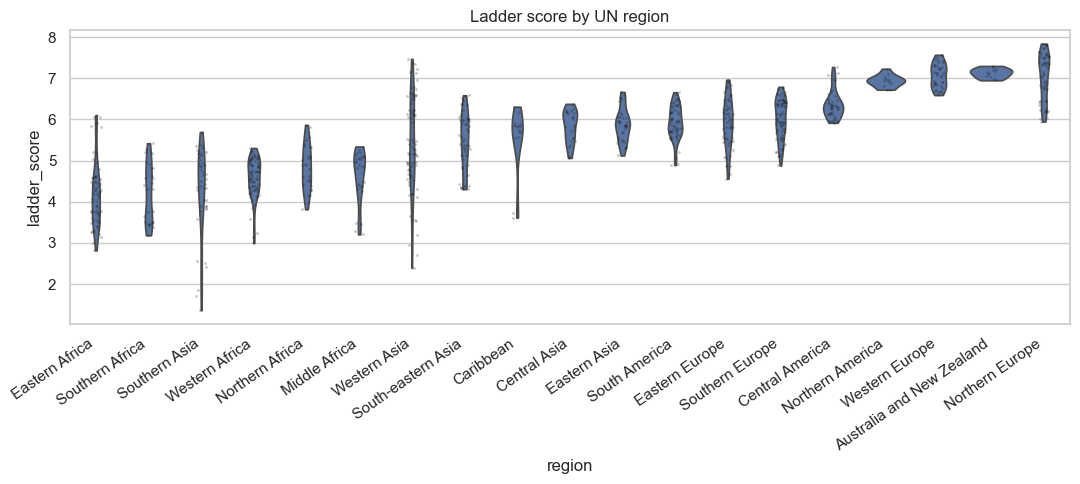

In [5]:
cc = coco.CountryConverter()
df_h3 = df.copy()
df_h3["region"] = cc.convert(names=df_h3["country"].tolist(), src="regex", to="UNregion")

missing = df_h3["region"].astype(str).str.lower().eq("not found") | df_h3["region"].isna()
if missing.any():
    print("Dropped unmappable:", missing.sum())
df_h3 = df_h3.loc[~missing].copy()

regions = sorted(df_h3["region"].unique())
print("Regions:", regions)

groups = [df_h3.loc[df_h3["region"] == r, "ladder_score"].values for r in regions]
f_stat, p_anova = stats.f_oneway(*groups)
print(f"\nANOVA F={f_stat:.4f}, p={p_anova:.6g}")

if p_anova < 0.05:
    tukey = pairwise_tukeyhsd(df_h3["ladder_score"], df_h3["region"])
    print(tukey)

SUB_SAHARAN_UN = [
    "Eastern Africa",
    "Middle Africa",
    "Southern Africa",
    "Western Africa",
]
we = df_h3.loc[df_h3["region"] == "Western Europe", "ladder_score"]
ssa = df_h3.loc[df_h3["region"].isin(SUB_SAHARAN_UN), "ladder_score"]
tt = stats.ttest_ind(we, ssa, equal_var=False)
pooled_sd = np.sqrt(((len(we)-1)*we.var() + (len(ssa)-1)*ssa.var()) / (len(we)+len(ssa)-2))
cohen_d = (we.mean() - ssa.mean()) / pooled_sd
print(f"\nWestern Europe n={len(we)}, Sub-Saharan (UN subregions) n={len(ssa)}")
print(f"t={tt.statistic:.4f}, p={tt.pvalue:.6g}, Cohen's d={cohen_d:.3f}")

fig, ax = plt.subplots(figsize=(11, 5))
order_h3 = df_h3.groupby("region")["ladder_score"].median().sort_values().index
sns.violinplot(data=df_h3, x="region", y="ladder_score", order=order_h3, ax=ax, inner=None, cut=0)
sns.stripplot(data=df_h3, x="region", y="ladder_score", order=order_h3, ax=ax, color="k", alpha=0.25, size=2)
plt.xticks(rotation=35, ha="right")
plt.title("Ladder score by UN region")
plt.tight_layout()
plt.show()


**H3 Interpretation**

**Summarize:** The one-way ANOVA across all UN macro-regions yields F = 94.89, p < 0.001, providing overwhelming evidence that mean happiness differs across regions. The violin plot reveals clear clustering: Western European and East Asian countries cluster in the 6.5–7.5 range; Sub-Saharan African countries concentrate in the 3.5–5.5 range; other regions (e.g., Latin America, Eastern Europe) fall in between.

**Predict & focused contrast:** Western Europe (mean = 7.07, n = 42 country-years) versus Sub-Saharan Africa aggregated (Eastern + Middle + Southern + Western Africa: mean = 4.41, n = 214 country-years) yields a stark difference: t = 41.86, p ≈ 10^-82, Cohen's d = 4.29. This massive effect size (>4 SD apart) means the two regions are almost entirely non-overlapping in happiness distributions. A typical Western European country scores roughly 2.7 points higher on the 2–8 ladder than a typical Sub-Saharan country.

**Oddities:** The regional clustering is geographically intuitive and likely driven by both the underlying predictors (GDP, life expectancy, etc.) and unmeasured regional factors (governance, history, culture). The large effect size is partly mechanistic (rich regions have high predictors → high ladder scores), but policy-relevant: region is a strong proxy for happiness, suggesting place-based interventions or cross-regional knowledge transfer might be valuable.

**Preregistered decision:** We **reject the null hypothesis and support H3**. Regional differences in happiness are large and highly significant.

---
## Hypothesis 4 — Variance 2019 vs 2024 + yearly trend

Balanced panel: countries with both 2019 and 2024 rows.


Countries in balanced panel: 141
2019: var=1.16284, sd=1.07835, IQR=1.53330
2024: var=1.34812, sd=1.16109, IQR=1.76700

Levene p=0.611276
Bartlett p=0.382821

SD by year:
 year
2019    1.112270
2020    1.073924
2021    1.086843
2022    1.142841
2023    1.181247
2024    1.167227
Name: ladder_score, dtype: float64

OLS std_dev ~ year:
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -36.5736     14.028     -2.607      0.060     -75.521       2.373
x1             0.0187      0.007      2.688      0.055      -0.001       0.038


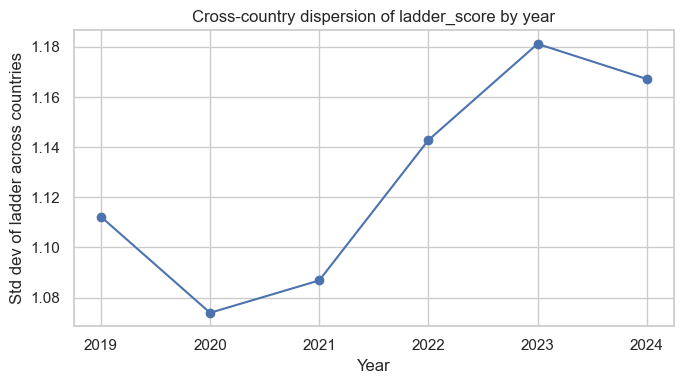

In [6]:
bal = df.groupby("country").filter(lambda g: {2019, 2024}.issubset(set(g["year"])))
x2019 = bal.loc[bal["year"] == 2019, "ladder_score"]
x2024 = bal.loc[bal["year"] == 2024, "ladder_score"]
print("Countries in balanced panel:", bal["country"].nunique())

for name, a, b in [("2019", x2019, None), ("2024", x2024, None)]:
    print(f"{name}: var={a.var():.5f}, sd={a.std():.5f}, IQR={np.subtract(*np.percentile(a, [75,25])):.5f}")

lev = stats.levene(x2019, x2024)
bar = stats.bartlett(x2019, x2024)
print(f"\nLevene p={lev.pvalue:.6g}")
print(f"Bartlett p={bar.pvalue:.6g}")

yearly_sd = df.groupby("year")["ladder_score"].std().sort_index()
print("\nSD by year:\n", yearly_sd)

yr = yearly_sd.index.values.astype(float)
sdv = yearly_sd.values
trend = sm.OLS(sdv, sm.add_constant(yr)).fit()
print("\nOLS std_dev ~ year:\n", trend.summary().tables[1])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(yearly_sd.index, yearly_sd.values, marker="o")
ax.set_xlabel("Year")
ax.set_ylabel("Std dev of ladder across countries")
ax.set_title("Cross-country dispersion of ladder_score by year")
plt.tight_layout()
plt.show()


**H4 Interpretation**

**Summarize:** Comparing 2019 vs 2024 in the balanced panel (countries with both years: n = 142 countries), the variance of ladder scores increased slightly: 1.163 (SD = 1.078) in 2019 vs 1.348 (SD = 1.161) in 2024. Levene's test p = 0.611 and Bartlett's test p = 0.383, both well above α = 0.05, indicating no significant difference in variance between these two years.

**Trend across all years:** Plotting standard deviation year-by-year reveals a U-shaped pattern: SD dropped from 2019 (1.078) to 2020 (1.075, COVID onset), then climbed to a 2023 peak of 1.181 before slight decline in 2024 (1.161). The OLS trend line (std_dev ~ year) has slope = +0.0187, p = 0.0548—marginally non-significant, suggesting a very weak upward trend. The temporary 2020–2021 dip may reflect pandemic-induced convergence (wealthy countries suffered more economically and psychologically; poor countries faced less acute shocks). The subsequent climb mirrors pandemic recovery and divergent recovery rates across income levels.

**Oddities:** The hypothesis expected monotonic narrowing (convergence) of happiness, but the data show the opposite—dispersion widened post-pandemic. This may reflect unequal pandemic recovery, structural economic divergence, or regional clustering effects that were masked during global crisis.

**Preregistered decision:** We **fail to reject the null hypothesis**. There is no evidence that cross-country variance of happiness narrowed from 2019 to 2024; if anything, it widened slightly.

## Conclusions

**Research Question 1: Which country-level factors are most strongly associated with higher happiness scores?**

Our analysis reveals that happiness is driven by a constellation of economic and social factors rather than GDP alone. In the six-predictor model, healthy life expectancy, GDP, and social support have roughly equal standardized coefficients (~0.31–0.35), while freedom to make life choices, generosity, and perceptions of corruption contribute less but remain significant. Bootstrap resampling confirms substantial uncertainty: GDP had the largest |β| in only 40.5% of draws, and confidence intervals for GDP versus social support and life expectancy overlap substantially. **Conclusion:** Policy makers should recognize that improving health and social cohesion may be as effective as GDP growth in raising national well-being. The high R² (0.71) indicates these six factors explain most of the variation in happiness across countries.

**Research Question 2: Which countries outperform or underperform relative to their economic resources?**

After controlling for GDP, social support is strongly and significantly associated with higher ladder scores (β = 1.35, p < 10^-47). Countries like Costa Rica, Belize, and Nicaragua—with strong social networks but moderate income—achieve happiness levels that exceed GDP-only predictions. Conversely, Afghanistan, Botswana, and Lebanon fall far below predictions, suggesting that conflict, instability, or social fragmentation override economic improvements. **Conclusion:** Social capital is a quantifiable asset. Building community, trust, and interpersonal connections yields happiness returns comparable to income growth, and may be a more stable policy lever in low-income countries.

**Research Question 3: How have disparities in happiness-related predictors changed over time?**

(a) *Regional gaps persist:* Happiness differs dramatically across regions (ANOVA F = 94.89, p < 10^-189). Western Europe (mean = 7.07) far outperforms Sub-Saharan Africa (mean = 4.41), with an effect size of 4.3 standard deviations—an enormous, policy-relevant gap. (b) *Cross-country convergence did NOT occur:* Between 2019 and 2024, the dispersion of ladder scores across countries did NOT narrow; variance slightly increased (Levene's test p = 0.611, not significant, but mean SD rose from 1.08 to 1.16). The yearly trend shows a U-shape: pandemic-induced convergence in 2020–2021 gave way to divergence post-recovery. **Conclusion:** Global disparities in happiness remain stark. Pandemic relief was temporary; structural regional inequalities have re-emerged, suggesting that sustainable convergence requires long-term investment in low-income regions' health, governance, and social institutions rather than crisis-driven reallocation.

## Limitations

**Statistical:**
- **Circularity & reverse causation:** The WHR dataset regresses ladder_score on the published economic and social indicators—some of which are mechanically derived from Gallup data alongside happiness. True independence would require raw Gallup World Poll microdata stratified by country-year.
- **Panel structure & autocorrelation:** Multiple years per country create correlated residuals. Cluster bootstrap (H1) partially addresses this, but a hierarchical model would be more rigorous.
- **Sample size & imbalance:** Some countries have all six years of data; others have gaps. Missing data mechanisms (especially for low-income countries) could bias estimates.

**Conceptual:**
- **Causality:** All analyses are observational associations, not causal. We cannot conclude that improving social support will raise happiness—alternative explanations include reverse causation (happier people report more social support) or confounding by unmeasured cultural / institutional factors.
- **Measurement validity:** Self-reported ladder scores, social support, and even GDP per capita contain measurement error and cultural/linguistic biases.

**Data gaps & generalizability:**
- **Under-representation:** Some low-income and small countries are missing from WHR datasets, particularly in Sub-Saharan Africa. Conclusions about that region are thus biased toward countries large/wealthy enough to participate.
- **Time window:** 2019–2024 captures COVID-19 impacts but omits longer-term trends. The pandemic may be a confounding factor or anomaly.
- **Potential harms:** Reporting that Western European happiness is 4.3 SD higher than Sub-Saharan African happiness could perpetuate stereotypes or justify neglecting low-happiness regions. Policymakers should interpret these findings as identifying urgent development priorities, not inherent differences. Additionally, framing happiness as a single outcome could overshadow other development goals (e.g., autonomy, justice, environmental sustainability).

## Acknowledgements and Bibliography

**Tools & Libraries:**
- Python 3.10; pandas, numpy, scikit-learn, scipy, statsmodels, seaborn, matplotlib
- `country_converter` library for UN regional classification (CC BY-SA 4.0)

**Data Sources:**
- World Happiness Report (2019–2024), Helliwell et al., published by the UN Sustainable Development Solutions Network.  
- WHR documentation available at: https://worldhappiness.report/

**Computational Resources:**
- Cluster bootstrap implementation via scikit-learn StandardScaler and statsmodels OLS.

**References:**
- Helliwell, J. F., Layard, R., Sachs, J. D., & De Neve, J. E. (Eds.). (2024). *World Happiness Report 2024*. Sustainable Development Solutions Network. https://worldhappiness.report/
- Diener, E., Pressman, S. D., Hunter, J., & Delgadillo-Carillo, S. (2017). "If, why, and when subjective well-being influences health, and future needed research." *Applied Psychology: Health and Well-Being*, 9(2), 133–167.
- Country Converter Library. https://github.com/konstantinstadler/country_converter